In [1]:
import sys
import pathlib
import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate the repository root (the directory that contains simulation_engine) so the
# notebook runs regardless of the directory Jupyter was launched from.
repository_path = pathlib.Path.cwd()
while not (repository_path / "simulation_engine").is_dir() and repository_path != repository_path.parent:
    repository_path = repository_path.parent
machine_learning_path = repository_path / "notebooks" / "machine_learning"
for path_entry in (str(repository_path), str(machine_learning_path)):
    if path_entry not in sys.path:
        sys.path.insert(0, path_entry)

import simulation_engine.rl as rl
import rl_helpers.rl_plots as rl_plots

data_rl_path = repository_path / "data" / "rl"

%matplotlib inline
%load_ext autoreload
%autoreload 2

# 5 - What did the agent learn?

A trained Q-table is interpretable: the greedy action in each state *is* the learned policy. This
notebook opens the joint Q-learning tables (player count 7) and compares them to the hand-written
rules.

## The learned mission policy

We load the mission agent and, for every state it actually visited, read off the greedy action
category. Aggregating by (volcano urgency, boat parts built) - taking the majority action over the
other features - shows the shape of the policy. Cells the agent never visited are marked unseen.

mission states learned: 677


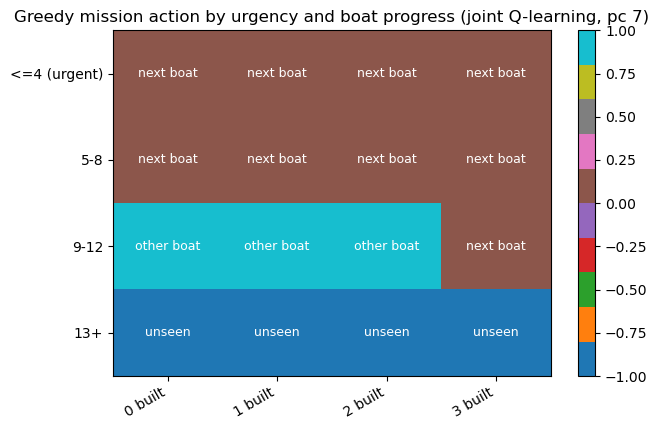

In [2]:
mission_agent = rl.load_agent(data_rl_path / 'agent_mission_joint_q_learning_pc7')
print('mission states learned:', mission_agent.visited_state_count)

category_labels = {0: 'next boat', 1: 'other boat', 2: 'fire', 3: 'food', 4: 'shelter', -1: 'unseen'}
votes_by_cell = collections.defaultdict(list)
for state_key, action_row in mission_agent.table_items():
    urgency, boat_progress = state_key[0], state_key[1]
    votes_by_cell[(urgency, boat_progress)].append(int(np.argmax(action_row)))

urgency_labels = ['<=4 (urgent)', '5-8', '9-12', '13+']
boat_progress_values = sorted({key[1] for key in votes_by_cell})
grid = []
for urgency in range(4):
    grid_row = []
    for boat_progress in boat_progress_values:
        votes = votes_by_cell.get((urgency, boat_progress))
        grid_row.append(collections.Counter(votes).most_common(1)[0][0] if votes else -1)
    grid.append(grid_row)

figure = rl_plots.plot_policy_heatmap(
    grid,
    row_labels = urgency_labels,
    column_labels = [f'{value} built' for value in boat_progress_values],
    title = 'Greedy mission action by urgency and boat progress (joint Q-learning, pc 7)',
    value_labels = category_labels,
    colour_map = 'tab10',
)
plt.show()

The baseline only prioritises boats once the volcano deck is short (its urgency threshold). The
learned policy instead takes the **next-needed boat part across the urgent and mid-urgency rows**,
i.e. it commits to building the boat earlier and more consistently than the baseline does. That more
aggressive boat-rush is exactly why the mission-only agent wins more often (notebook 4). In the
calmest states (many cards left, rarely reached) the policy is sparser and less decisive.

## The learned participant policy

The participant agent learns an *include margin* $Q(\text{include}) - Q(\text{exclude})$ per
candidate state; a positive margin means "prefer to staff this candidate". We tabulate the margin
against the two most influential features in the baseline scoring heuristic: affordability and
whether the character's ability is active on the mission.

In [3]:
participant_agent = rl.load_agent(data_rl_path / 'agent_participant_joint_q_learning_pc7')
print('participant states learned:', participant_agent.visited_state_count)

afford_labels = {0: 'cannot', 1: 'exact', 2: 'surplus'}
ability_labels = {0: 'ability off', 1: 'ability on'}
margin_rows = []
for state_key, action_row in participant_agent.table_items():
    afford_index, ability_active = state_key[0], state_key[1]
    include_margin = action_row[rl.PARTICIPANT_ACTION_INCLUDE] - action_row[rl.PARTICIPANT_ACTION_EXCLUDE]
    margin_rows.append({
        'afford': afford_labels[afford_index],
        'ability': ability_labels[ability_active],
        'include_margin': include_margin,
    })
margin_frame = pd.DataFrame(margin_rows)
margin_frame.groupby(['afford', 'ability'])['include_margin'].mean().round(3)

participant states learned: 48


afford   ability    
exact    ability off   -0.026
         ability on    -0.011
surplus  ability off    0.004
         ability on    -0.003
Name: include_margin, dtype: float64

## Caveats

These tables show only states the agent actually visited; unvisited keys fall back to a default
greedy choice and are not evidence of a learned preference. The abstraction is also lossy by design,
so two genuinely different board positions can share a key. Read the policy as a summary of
tendencies, not a per-position oracle.

Taken together with notebook 4, the picture is consistent. For mission choice the learned policy
rushes the next-needed boat part not only when urgent but across mid-urgency states too - building
the boat more aggressively than the baseline - which is why mission-only learning wins more. For
staffing, the learned include-margins only weakly track affordability and ability, far more coarsely
than the hand-tuned scoring weights, which is why participant-only learning trails the baseline.